In [1]:
import sys
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [2]:
# sys.path.append("/home/alexis/Documents/COMP558/COMP558-FinalProject/code/")
sys.path.append("/workspaces/python-opencv/repo/code/")

In [3]:
from tracker import Tracker
from optical_flow.bounding_box import BoundingBox
from feature_detection.shi_tomasi import ShiTomasiDetector
from feature_description.orb_descriptor import ORBDescriptor
from optical_flow.lucas_kanade import LucasKanade
from segmentation.fuzzy_c_means import FuzzyCMeansSegmenter

In [4]:
video_name = "videos/VIDEO-20250109-160653.mp4"
depth_name = "videos/DEPTH-20250109-160653.mp4"

output_name = "out/complete.mp4"

In [5]:
x, y, w, h = 255, 280, 160, 95

shi_tomasi_params = dict(params = dict( maxCorners = 1000, qualityLevel = 0.01, minDistance = 5, blockSize = 5))
orb_params = {"params": {"nfeatures" : 10000, "edgeThreshold" : 5, "patchSize" : 5}}
# gu_params = {"_lambda" : 4/5, "frame_buffer" : 10, "gamma" : 1, "gamma_area" : 0.01, "gamma_drift" : 0.1}
gu_params = {"_lambda" : 4/5, "frame_buffer" : 60, "gamma" : 0.1, "gamma_area" : 0.01, "gamma_drift" : 0.1}
lucas_kanade_params = {}
c_means_params = {"n_groups" : 5, "target_error" : 0, "neighbourhood_size" : 10, "m" : 2, "lambda_val" : 2, "max_iter" : 10}

In [6]:
initial_bbox = BoundingBox(x, y, w, h)
feature_detector = ShiTomasiDetector(**shi_tomasi_params)
feature_descriptor = ORBDescriptor(**orb_params)
optical_flow = LucasKanade(**lucas_kanade_params)
segmenter = FuzzyCMeansSegmenter(**c_means_params)

In [7]:
cap_video = cv.VideoCapture(video_name)
cap_depth = cv.VideoCapture(depth_name)

ret_video, frame_video = cap_video.read()
ret_depth, frame_depth = cap_depth.read()

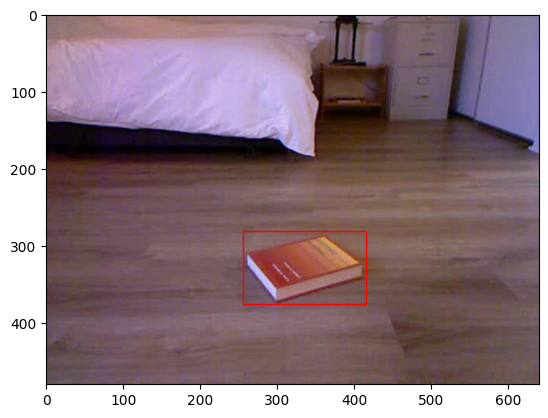

In [8]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])

rect = patches.Rectangle((initial_bbox.x, initial_bbox.y), initial_bbox.w, initial_bbox.h, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [9]:
tracker = Tracker(frame_video, initial_bbox, feature_detector, optical_flow, feature_descriptor, segmenter, gu_params)

In [10]:
fps = cap_video.get(cv.CAP_PROP_FPS)

fourcc = cv.VideoWriter_fourcc(*'mp4v')
video_writer = cv.VideoWriter(output_name, fourcc, fps, frame_video.shape[:-1][::-1])

In [11]:
# target is ~4:24
length = int(cap_video.get(cv.CAP_PROP_FRAME_COUNT))

for i in tqdm(range(length)):

    if not (ret_video and ret_depth):
        break

    bbox = tracker.track(frame_video)

    img2 = cv.rectangle(frame_video, (bbox.x, bbox.y), (bbox.x + bbox.w, bbox.y + bbox.h), 255, 2)

    video_writer.write(img2)

    ret_video, frame_video = cap_video.read()
    ret_depth, frame_depth = cap_depth.read()

100%|██████████| 356/356 [06:10<00:00,  1.04s/it]


In [12]:
video_writer.release()